# Credit-G Decision Tree

In [30]:
import pandas as pd
from scipy.io import arff
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
 )

In [31]:
from scipy.io import arff
import pandas as pd

# Load ARFF dataset
data, meta = arff.loadarff("dataset_31_credit-g.arff")

# Convert to pandas dataframe
df = pd.DataFrame(data)

# Decode byte strings to normal strings
for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode("utf-8")

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [32]:
# creating the dataset using onehot encoding

df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8')
        except Exception:
            pass

categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

target_col = None
for candidate in ['class', 'target', 'label', 'y']:
    if candidate in df.columns:
        target_col = candidate
        break

ohe_cols = [c for c in categorical_cols if c != target_col]
df_ohe = pd.get_dummies(df, columns=ohe_cols, drop_first=False, dtype=int)

if target_col is not None:
    X_ohe = df_ohe.drop(columns=[target_col])
    y = df_ohe[target_col]
else:
    X_ohe = df_ohe

print(f"Raw df shape: {df.shape}")
print(f"One-hot df_ohe shape: {df_ohe.shape}")
print(f"One-hot features shape (X_ohe): {X_ohe.shape}")
if target_col is not None:
    print(f"Target column: {target_col} (dtype={y.dtype})")

Raw df shape: (1000, 21)
One-hot df_ohe shape: (1000, 62)
One-hot features shape (X_ohe): (1000, 61)
Target column: class (dtype=object)


In [33]:
X_encoded = X_ohe.copy()
y_encoded = y.copy() 

class_names = sorted(pd.Series(y_encoded).unique().tolist())

X_encoded.head()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_0<=X<200,checking_status_<0,checking_status_>=200,...,housing_own,housing_rent,job_high qualif/self emp/mgmt,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_none,own_telephone_yes,foreign_worker_no,foreign_worker_yes
0,6.0,1169.0,4.0,4.0,67.0,2.0,1.0,0,1,0,...,1,0,0,1,0,0,0,1,0,1
1,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,1,0,0,...,1,0,0,1,0,0,1,0,0,1
2,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,0,0,0,...,1,0,0,0,0,1,1,0,0,1
3,42.0,7882.0,2.0,4.0,45.0,1.0,2.0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
4,24.0,4870.0,3.0,4.0,53.0,2.0,2.0,0,1,0,...,0,0,0,1,0,0,1,0,0,1


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded,
 )

## Depth-Limited Tree (max_depth=5)

In [35]:
clf_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_5.fit(X_train, y_train)
y_pred_5 = clf_5.predict(X_test)

print(f"Train accuracy: {accuracy_score(y_train, clf_5.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_pred_5):.4f}")

Train accuracy: 0.7929
Test accuracy:  0.6967


In [36]:
if len(class_names) == 2:
    pos_label = 'good' if 'good' in class_names else class_names[1]
    print(f"Positive class (pos_label): {pos_label}")
    print(f"Precision: {precision_score(y_test, y_pred_5, pos_label=pos_label, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_5, pos_label=pos_label, zero_division=0):.4f}")
    print(f"F1:        {f1_score(y_test, y_pred_5, pos_label=pos_label, zero_division=0):.4f}")
else:
    print(f"Precision (weighted): {precision_score(y_test, y_pred_5, average='weighted', zero_division=0):.4f}")
    print(f"Recall (weighted):    {recall_score(y_test, y_pred_5, average='weighted', zero_division=0):.4f}")
    print(f"F1 (weighted):        {f1_score(y_test, y_pred_5, average='weighted', zero_division=0):.4f}")

print()
print(classification_report(y_test, y_pred_5, labels=class_names))

Positive class (pos_label): good
Precision: 0.7532
Recall:    0.8429
F1:        0.7955

              precision    recall  f1-score   support

         bad       0.49      0.36      0.41        90
        good       0.75      0.84      0.80       210

    accuracy                           0.70       300
   macro avg       0.62      0.60      0.60       300
weighted avg       0.67      0.70      0.68       300



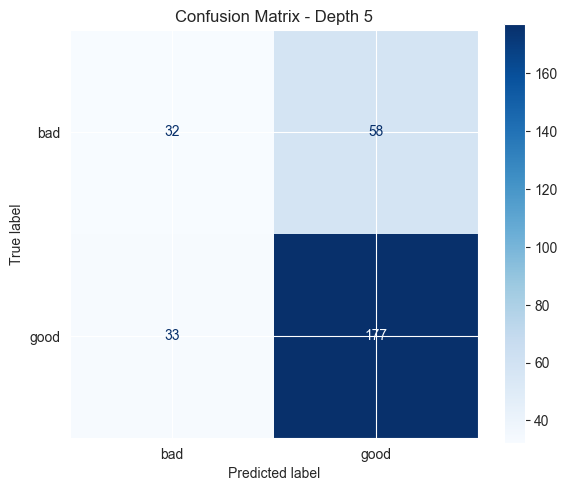

In [37]:
cm_5 = confusion_matrix(y_test, y_pred_5, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_5, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix - Depth 5')
plt.tight_layout()
plt.show()

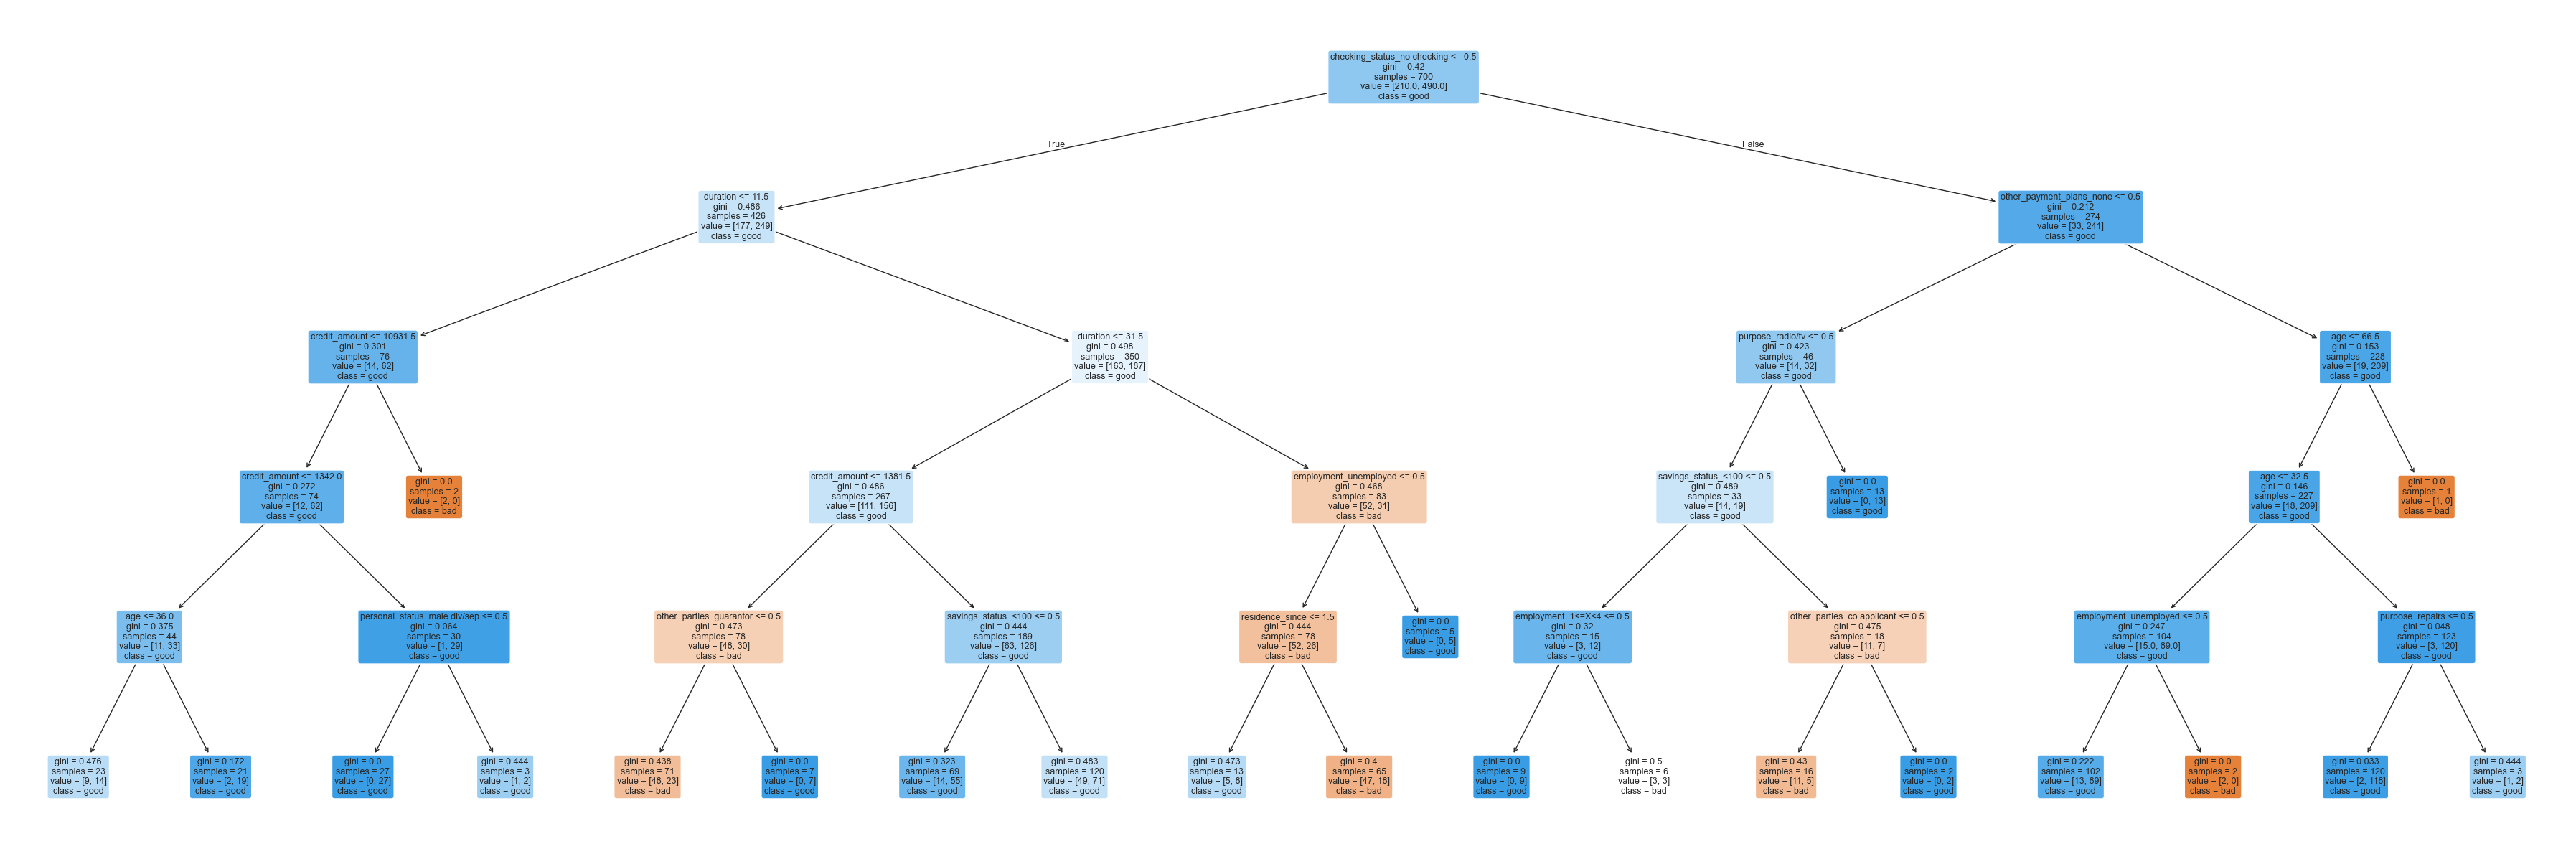

In [38]:
fig, ax = plt.subplots(figsize=(36, 12))
plot_tree(
    clf_5,
    feature_names=X_encoded.columns.tolist(),
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
 )
plt.tight_layout()
plt.savefig('decision_tree_depth5.png', dpi=150, bbox_inches='tight')
plt.show()

## Depth-Limited Tree (max_depth=3)

In [39]:
clf_d3 = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_d3.fit(X_train, y_train)
y_pred_d3 = clf_d3.predict(X_test)

print(f"Train accuracy: {accuracy_score(y_train, clf_d3.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_pred_d3):.4f}")

Train accuracy: 0.7343
Test accuracy:  0.7133


In [40]:
if len(class_names) == 2:
    pos_label = 'good' if 'good' in class_names else class_names[1]
    print(f"Positive class (pos_label): {pos_label}")
    print(f"Precision: {precision_score(y_test, y_pred_d3, pos_label=pos_label, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_d3, pos_label=pos_label, zero_division=0):.4f}")
    print(f"F1:        {f1_score(y_test, y_pred_d3, pos_label=pos_label, zero_division=0):.4f}")
else:
    print(f"Precision (weighted): {precision_score(y_test, y_pred_d3, average='weighted', zero_division=0):.4f}")
    print(f"Recall (weighted):    {recall_score(y_test, y_pred_d3, average='weighted', zero_division=0):.4f}")
    print(f"F1 (weighted):        {f1_score(y_test, y_pred_d3, average='weighted', zero_division=0):.4f}")

print()
print(classification_report(y_test, y_pred_d3, labels=class_names))

Positive class (pos_label): good
Precision: 0.7331
Recall:    0.9286
F1:        0.8193

              precision    recall  f1-score   support

         bad       0.56      0.21      0.31        90
        good       0.73      0.93      0.82       210

    accuracy                           0.71       300
   macro avg       0.65      0.57      0.56       300
weighted avg       0.68      0.71      0.67       300



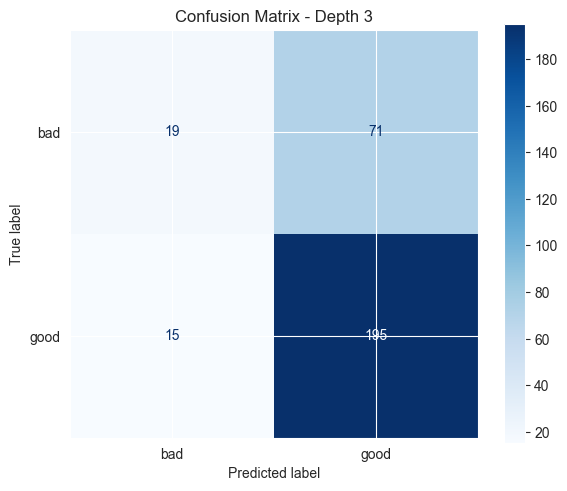

In [41]:
cm_d3 = confusion_matrix(y_test, y_pred_d3, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_d3, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix - Depth 3')
plt.tight_layout()
plt.show()

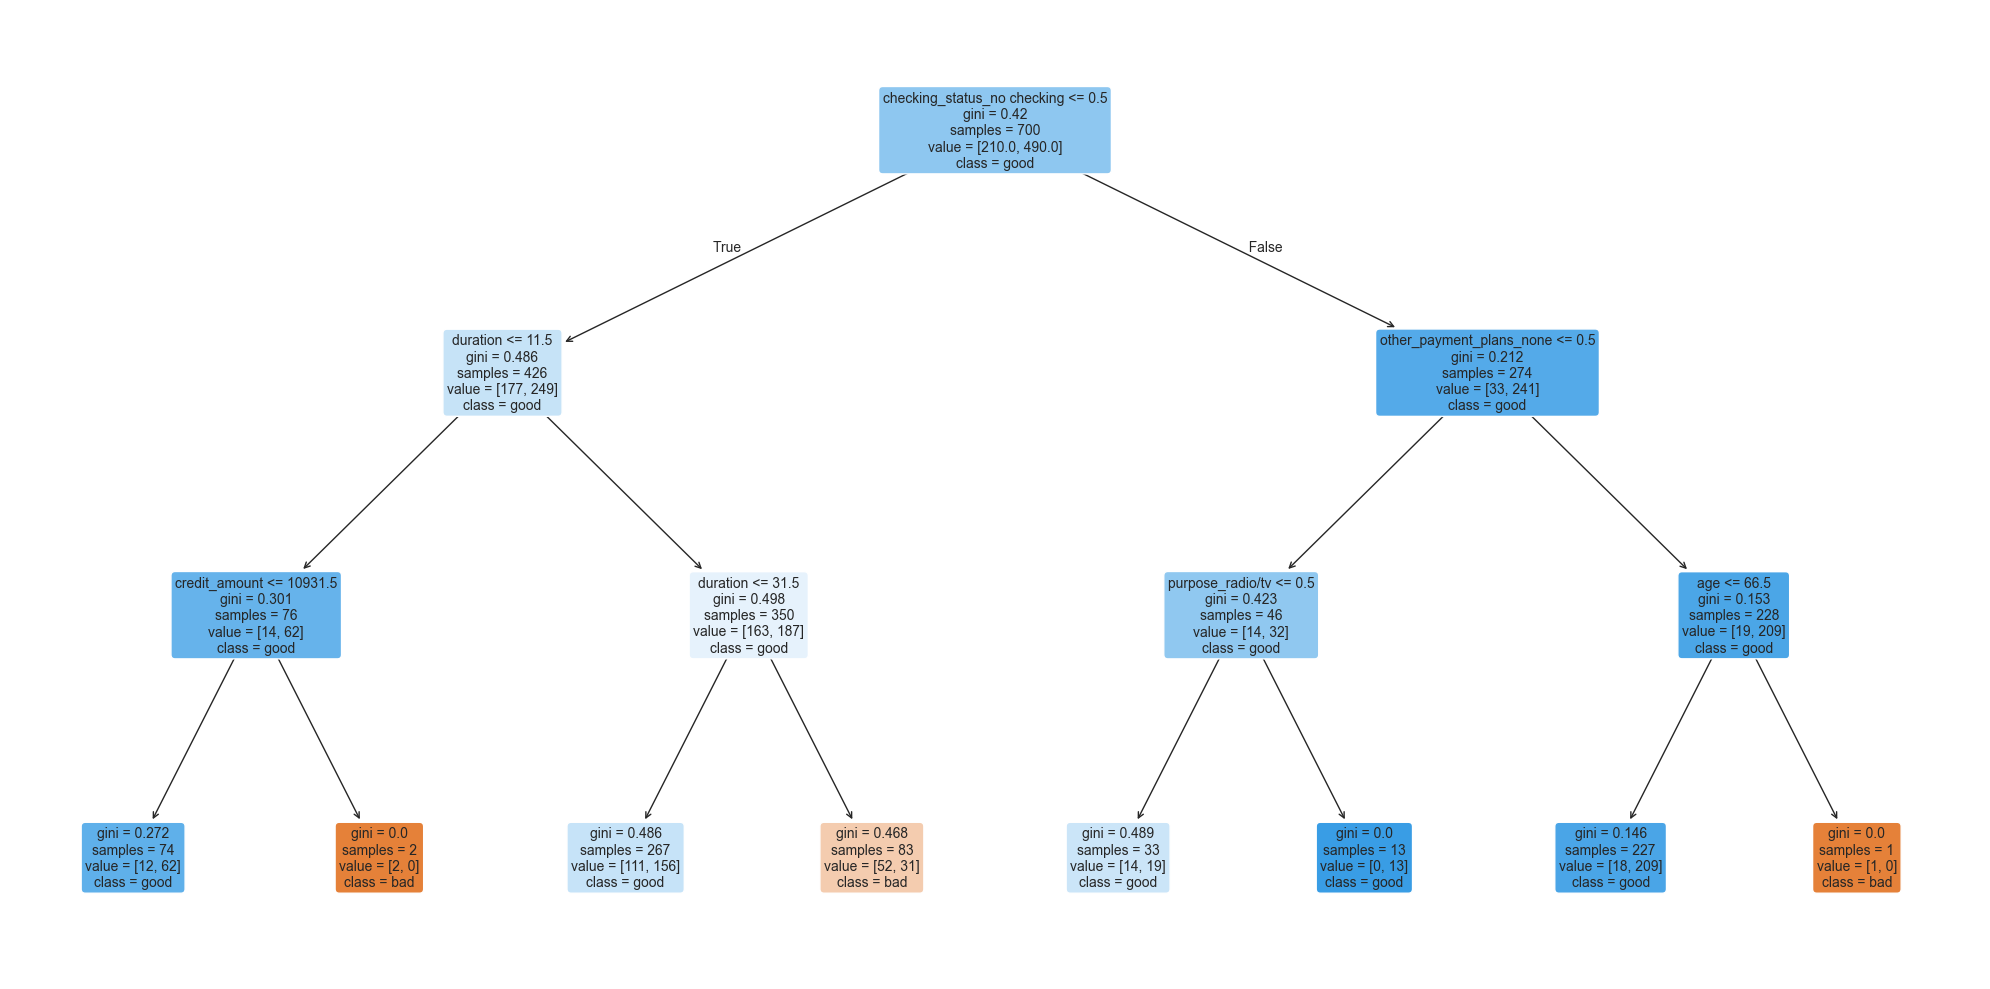

In [42]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    clf_d3,
    feature_names=X_encoded.columns.tolist(),
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
 )
plt.tight_layout()
plt.savefig('decision_tree_depth3.png', dpi=150, bbox_inches='tight')
plt.show()

## Explainability part

In [43]:
#model select
tree_model = clf_d3
tree_name = "Decision Tree (depth=3)"

print("Explaining:", tree_name)
print("Classes:", list(tree_model.classes_))
print("Number of features seen by tree:", tree_model.n_features_in_)

Explaining: Decision Tree (depth=3)
Classes: ['bad', 'good']
Number of features seen by tree: 61


Top feature importances:


,importance
checking_status_no checking,0.517769
duration,0.276815
other_payment_plans_none,0.066689
purpose_radio/tv,0.059868
credit_amount,0.048757
age,0.030102
residence_since,0.000000
checking_status_0<=X<200,0.000000
existing_credits,0.000000
checking_status_<0,0.000000


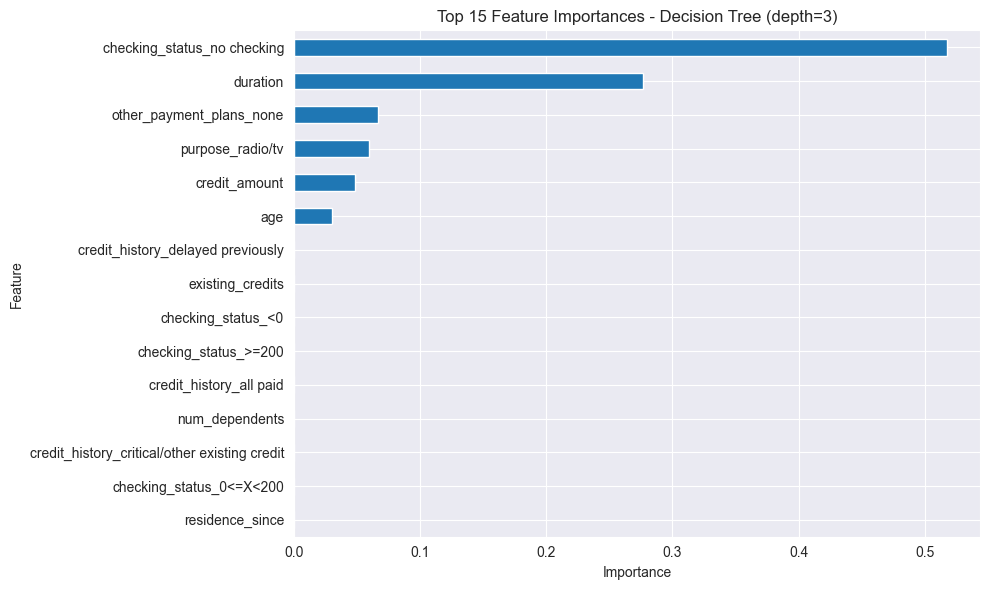

In [44]:
#feature importance
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    tree_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_k = 15
top_importances = importances.head(top_k)

print("Top feature importances:")
display(top_importances.to_frame("importance"))

plt.figure(figsize=(10, 6))
top_importances.sort_values().plot(kind="barh")
plt.title(f"Top {top_k} Feature Importances - {tree_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [45]:
#case picker
import numpy as np

def _label_to_str(v):
    return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else str(v)

pred_dt = tree_model.predict(X_test)
pred_dt_labels = np.array([_label_to_str(v) for v in pred_dt])
y_true_labels = np.array([_label_to_str(v) for v in y_test.values])

bad_candidates = np.where(pred_dt_labels == "bad")[0]
good_candidates = np.where(pred_dt_labels == "good")[0]
mis_candidates = np.where(pred_dt_labels != y_true_labels)[0]

bad_i = int(bad_candidates[0]) if len(bad_candidates) else None
good_i = int(good_candidates[0]) if len(good_candidates) else None

mis_i = None
for idx in mis_candidates:
    idx = int(idx)
    if idx != bad_i and idx != good_i:
        mis_i = idx
        break

if mis_i is None and len(mis_candidates):
    mis_i = int(mis_candidates[0])

print("Selected indices in DT test set:")
print({"bad": bad_i, "good": good_i, "mis": mis_i})

Selected indices in DT test set:
{'bad': 7, 'good': 0, 'mis': 8}


In [46]:
#local exp
def explain_dt_prediction(idx, model=tree_model):
    x_row = X_test.iloc[[idx]]
    pred_label = _label_to_str(model.predict(x_row)[0])
    true_label = _label_to_str(y_test.iloc[idx])
    proba = model.predict_proba(x_row)[0]

    print("=" * 80)
    print(f"Index       : {idx}")
    print(f"True label  : {true_label}")
    print(f"Prediction  : {pred_label}")
    print("Probabilities:")
    for cls, p in zip(model.classes_, proba):
        print(f"  {cls}: {p:.4f}")

if bad_i is not None:
    explain_dt_prediction(bad_i)

if good_i is not None:
    explain_dt_prediction(good_i)

if mis_i is not None:
    explain_dt_prediction(mis_i)

Index       : 7
True label  : bad
Prediction  : bad
Probabilities:
  bad: 0.6265
  good: 0.3735
Index       : 0
True label  : bad
Prediction  : good
Probabilities:
  bad: 0.0793
  good: 0.9207
Index       : 8
True label  : bad
Prediction  : good
Probabilities:
  bad: 0.0000
  good: 1.0000


In [47]:
#decision paths
from sklearn.tree import _tree

def print_decision_path(model, X_df, idx):
    feature_names = list(X_df.columns)
    x_instance = X_df.iloc[[idx]]

    node_indicator = model.decision_path(x_instance)
    leaf_id = model.apply(x_instance)[0]

    print("=" * 80)
    print(f"Decision path for test instance {idx}")
    print(f"Leaf node reached: {leaf_id}")

    node_index = node_indicator.indices[
        node_indicator.indptr[0]:node_indicator.indptr[1]
    ]

    for node_id in node_index:
        if leaf_id == node_id:
            print(f"-> Reached leaf node {node_id}")
            continue

        feature_idx = model.tree_.feature[node_id]
        threshold = model.tree_.threshold[node_id]

        if feature_idx == _tree.TREE_UNDEFINED:
            continue

        feature_name = feature_names[feature_idx]
        feature_value = x_instance.iloc[0, feature_idx]

        if feature_value <= threshold:
            decision = "<="
        else:
            decision = ">"

        print(
            f"Node {node_id}: ({feature_name} = {feature_value}) "
            f"{decision} {threshold:.4f}"
        )


if bad_i is not None:
    print_decision_path(tree_model, X_test, bad_i)

if good_i is not None:
    print_decision_path(tree_model, X_test, good_i)

if mis_i is not None:
    print_decision_path(tree_model, X_test, mis_i)

Decision path for test instance 7
Leaf node reached: 7
Node 0: (checking_status_no checking = 0) <= 0.5000
Node 1: (duration = 36.0) > 11.5000
Node 5: (duration = 36.0) > 31.5000
-> Reached leaf node 7
Decision path for test instance 0
Leaf node reached: 13
Node 0: (checking_status_no checking = 1) > 0.5000
Node 8: (other_payment_plans_none = 1) > 0.5000
Node 12: (age = 44.0) <= 66.5000
-> Reached leaf node 13
Decision path for test instance 8
Leaf node reached: 11
Node 0: (checking_status_no checking = 1) > 0.5000
Node 8: (other_payment_plans_none = 0) <= 0.5000
Node 9: (purpose_radio/tv = 1) > 0.5000
-> Reached leaf node 11
